# Projeto Final - Aprendizado de Máquina
## Previsão de Evasão e Sucesso Acadêmico de Estudantes

---

## 1. Definição do Problema e do Tipo de Tarefa

### 1.1. Identificação do Grupo
* **Samuel Campos dos Santos** — GitHub: `@Tyxiel`
* **João Pedro Chaves** — GitHub: `@JPChaves1`
* **João Victor dos Santos** — GitHub: `@Joaovitor9821`

### 1.2. Contexto e Fonte dos Dados
Os dados utilizados neste trabalho foram obtidos no repositório público **UCI Machine Learning Repository**:
* **Dataset:** *Predict Students' Dropout and Academic Success*
* **Link de Acesso:** [UCI Repository - Dataset #697](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)

### 1.3. Objetivo do Projeto
O objetivo principal é construir e avaliar um modelo preditivo capaz de identificar precocemente estudantes em risco de evasão escolar (`Dropout`) ou com alta probabilidade de conclusão (`Graduate`). A identificação precoce permite que a instituição de ensino promova intervenções pedagógicas e assistenciais direcionadas antes do abandono efetivo do curso.

### 1.4. Atributo-Alvo e Tipo de Tarefa
* **Atributo-Alvo (`Target`):** Variável categórica nominal com três desfechos possíveis:
  * `Dropout`: Estudante que evadiu do curso.
  * `Enrolled`: Estudante que permanece matriculado.
  * `Graduate`: Estudante diplomado.
* **Tipo da Tarefa:** **Classificação Multiclasse** (pois o atributo-alvo é discreto e contém 3 categorias distintas).

### 1.5. Atributos Preditivos (Features)
A base possui **36 variáveis preditivas** agrupadas em quatro dimensões principais:
1. **Dados Demográficos:** Estado civil, gênero, nacionalidade e idade no ato da matrícula.
2. **Dados Socioeconômicos:** Escolaridade e ocupação dos pais, status de deslocado (*displaced*), necessidades educacionais especiais, bolsa de estudo, endividamento e adimplemento de mensalidades.
3. **Indicadores Macroeconômicos:** Taxa de desemprego, taxa de inflação e PIB regional do período.
4. **Desempenho Acadêmico:** Unidades curriculares creditadas, matriculadas, avaliadas, aprovadas e notas médias obtidas no 1º e no 2º semestres letivos.



---


## 2. Compreensão e Descrição dos Dados

Nesta seção, realizamos uma inspeção inicial no conjunto de dados para compreender a sua estrutura, dimensão, tipos de variáveis, presença de valores ausentes ou duplicados e a distribuição da variável-alvo (`Target`).

O dataset é composto por informações demográficas, socioeconômicas e de desempenho acadêmico obtidas no momento do ingresso e ao longo dos dois primeiros semestres letivos dos estudantes.

In [3]:
import pandas as pd

# 0. Carregar os dados direto do GitHub para garantir que a variável 'df' exista
url = "https://raw.githubusercontent.com/Tyxiel/projeto-final-fia/main/data.csv"
df = pd.read_csv(url, sep=';')

# 1. Dimensão do Dataset
linhas, colunas = df.shape
print(f" Dimensão do Dataset: {linhas} registros (linhas) e {colunas} atributos (colunas).\n")

# 2. Resumo dos tipos de dados
print("--- Tipos de Variáveis ---")
print(df.dtypes.value_counts())
print("\n--- Informações das Colunas ---")
df.info()

# 3. Verificação de Valores Ausentes (Missing Values)
nulos_totais = df.isnull().sum().sum()
print(f"\n Total de valores ausentes/nulos: {nulos_totais}")

# 4. Verificação de Linhas Duplicadas
duplicados = df.duplicated().sum()
print(f" Total de registros duplicados: {duplicados}")

# 5. Contagem e proporção do Atributo-Alvo
print("\n--- Distribuição da Variável-Alvo (Target) ---")
contagem_target = df['Target'].value_counts()
proporcao_target = df['Target'].value_counts(normalize=True) * 100

df_target_summary = pd.DataFrame({
    'Quantidade': contagem_target,
    'Porcentagem (%)': proporcao_target.round(2)
})
display(df_target_summary)

 Dimensão do Dataset: 4424 registros (linhas) e 37 atributos (colunas).

--- Tipos de Variáveis ---
int64      29
float64     7
object      1
Name: count, dtype: int64

--- Informações das Colunas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64

,Quantidade,Porcentagem (%)
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


### Interpretação e Análise Descritiva dos Dados

A partir da execução e inspeção estrutural da base de dados, observam-se as seguintes características fundamentais:

1. **Dimensão da Base:**
   * O conjunto de dados conta com **4.424 instâncias (estudantes)** e **37 colunas (atributos)**, representando uma quantidade consistente de informações para o treinamento de modelos de aprendizado de máquina.

2. **Tipos de Dados e Estrutura:**
   * **29 Atributos Inteiros (`int64`):** Compreendem variáveis numéricas discretas (como idade no ato da matrícula e unidades curriculares) e variáveis categóricas que já se encontram codificadas em formato numérico (ex: estado civil, curso, escolaridade e ocupação dos pais).
   * **7 Atributos Flutuantes (`float64`):** Variáveis numéricas contínuas associadas às notas de admissão, notas das unidades curriculares do 1º e 2º semestres e indicadores socioeconômicos (taxa de desemprego, taxa de inflação e PIB).
   * **1 Atributo do Tipo Objeto (`object`):** Trata-se da variável de saída/alvo (`Target`), composta por rótulos textuais representando a situação acadêmica do aluno.

3. **Qualidade dos Dados:**
   * **Inexistência de Ausentes:** Não há registros nulos ou ausentes (`0 valores nulos`), o que elimina a necessidade de imputação de dados faltantes.
   * **Inexistência de Duplicados:** Não foram identificadas linhas duplicadas na base de dados (`0 registros duplicados`), garantindo que não haverá viés por repetição direta de instâncias.

4. **Análise da Variável-Alvo (`Target`):**
   * A variável `Target` é composta por três classes distintas:
     * **`Graduate` (Graduado):** 2.209 alunos (49,93%)
     * **`Dropout` (Evasão):** 1.421 alunos (32,12%)
     * **`Enrolled` (Matriculado):** 794 alunos (17,95%)
   * **Implicações para o Aprendizado de Máquina:** A distribuição evidencia um **desbalanceamento moderado das classes**, no qual a classe de alunos diplomados representa quase metade do dataset, enquanto os alunos ainda matriculados correspondem a menos de 18%. Essa característica exige que a divisão entre dados de treino e teste utilize amostragem estratificada (`stratify`), além de direcionar a avaliação para métricas robustas ao desbalanceamento (como F1-score ponderado/macro e matriz de confusão).



---


## 3. Análise Exploratória de Dados (EDA)

Nesta seção, exploramos as relações entre as variáveis preditivas (demográficas, socioeconômicas e acadêmicas) e o status do estudante (`Target`). O objetivo é identificar quais fatores possuem maior impacto no sucesso ou na evasão acadêmica dos alunos.



---


### Figura 1: Situação Financeira (Mensalidades em Dia) vs Target

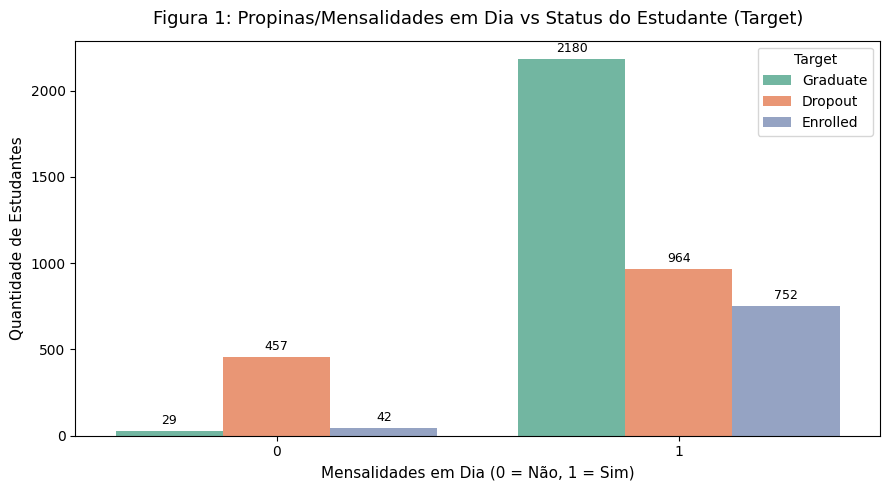

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df, x='Tuition fees up to date', hue='Target', palette='Set2')

plt.title('Figura 1: Propinas/Mensalidades em Dia vs Status do Estudante (Target)', fontsize=13, pad=12)
plt.xlabel('Mensalidades em Dia (0 = Não, 1 = Sim)', fontsize=11)
plt.ylabel('Quantidade de Estudantes', fontsize=11)
plt.legend(title='Target')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

#### Interpretação da Figura 1 (Mensalidades em Dia):
O gráfico revela um divisor de águas crucial no dataset:
* **Mensalidades Atrasadas (0):** A esmagadora maioria dos estudantes com propinas/mensalidades em atraso acaba evadindo (`Dropout`), com um número irrisório de formandos (`Graduate`).
* **Mensalidades em Dia (1):** Quase a totalidade dos estudantes graduados mantém as mensalidades em dia.
* **Conclusão:** O adimplemento financeiro (`Tuition fees up to date`) é um dos preditores mais fortes de permanência escolar no dataset, indicando que dificuldades financeiras estão diretamente ligadas ao abandono do curso.



---


### Figura 2: Desempenho Académico no 2º Semestre vs Target

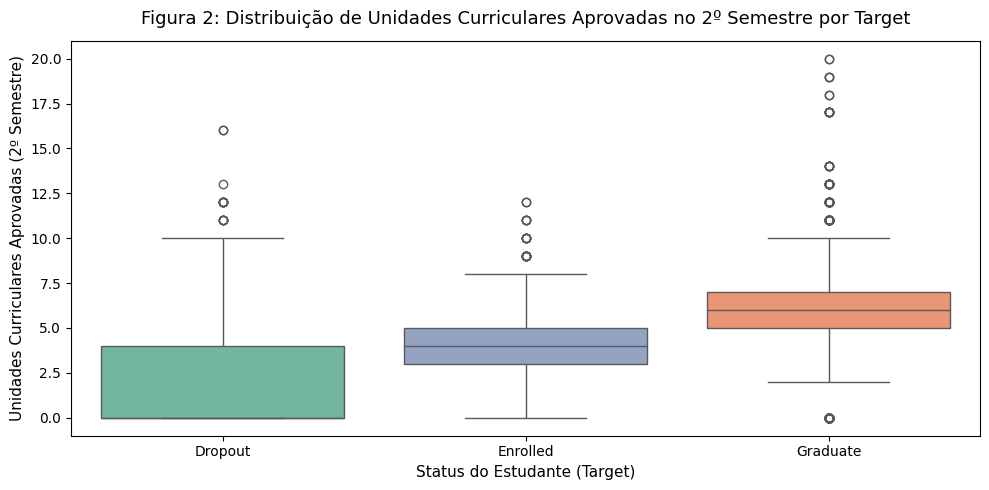

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='Target',
    y='Curricular units 2nd sem (approved)',
    hue='Target',
    palette='Set2',
    order=['Dropout', 'Enrolled', 'Graduate'],
    legend=False,
)

plt.title(
    'Figura 2: Distribuição de Unidades Curriculares Aprovadas no 2º Semestre'
    ' por Target',
    fontsize=13,
    pad=12,
)
plt.xlabel('Status do Estudante (Target)', fontsize=11)
plt.ylabel('Unidades Curriculares Aprovadas (2º Semestre)', fontsize=11)

plt.tight_layout()
plt.show()

#### Interpretação da Figura 2 (Aprovações no 2º Semestre):
A análise do desempenho acadêmico no segundo semestre evidencia forte discriminação entre as classes:
* **`Dropout`:** A mediana de aprovações é próxima ou igual a 0. A maioria dos estudantes que desistem aprova pouquíssimas ou nenhuma disciplina no 2º semestre.
* **`Graduate`:** Apresenta mediana de aprovações elevada (em torno de 6 disciplinas concluídas com sucesso), com baixa dispersão na parte inferior.
* **`Enrolled`:** Fica em uma posição intermediária, com alunos que aprovam uma quantidade moderada de disciplinas.
* **Conclusão:** O número de disciplinas aprovadas nos semestres iniciais é uma variável preditiva altamente discriminatória para classificar o sucesso acadêmico versus a evasão.



---


### Figura 3: Impacto da Idade no Momento da Matrícula

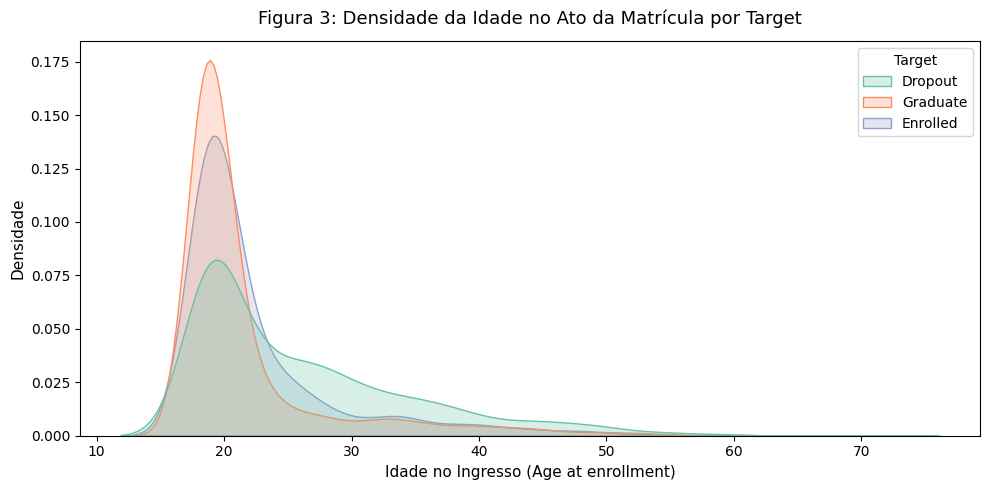

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Age at enrollment', hue='Target', common_norm=False, fill=True, palette='Set2')

plt.title('Figura 3: Densidade da Idade no Ato da Matrícula por Target', fontsize=13, pad=12)
plt.xlabel('Idade no Ingresso (Age at enrollment)', fontsize=11)
plt.ylabel('Densidade', fontsize=11)

plt.tight_layout()
plt.show()

#### Interpretação da Figura 3 (Idade do Aluno no Ingresso):
O gráfico de densidade de idade demonstra tendências distintas entre estudantes jovens e adultos:
* **Estudantes Jovens (~18 a 22 anos):** Concentram a maior proporção de formandos (`Graduate`).
* **Estudantes Mais Velhos (> 25 anos):** Apresentam uma cauda mais longa na curva de evasão (`Dropout`). Quanto maior a idade no momento do ingresso, maior a incidência de abandono escolar.
* **Conclusão:** Alunos ingressantes com idade mais avançada enfrentam desafios adicionais (como conciliação entre trabalho e estudo), tornando a idade no ingresso um fator de risco relevante para evasão.



---

### Figura 4: Matriz de Correlação das Variáveis Académicas

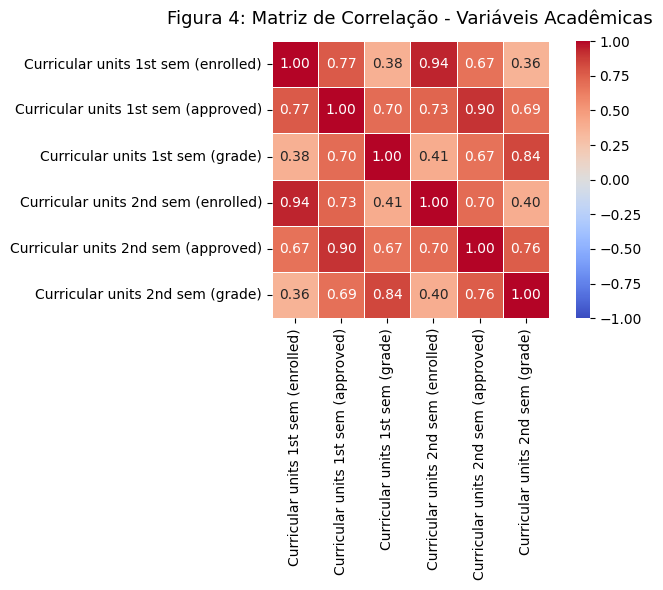

In [ ]:
# Seleção das colunas de desempenho acadêmico mais relevantes do 1º e 2º semestres
cols_academicas = [
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)'
]

plt.figure(figsize=(8, 6))
corr = df[cols_academicas].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=.5)

plt.title('Figura 4: Matriz de Correlação - Variáveis Acadêmicas', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

#### Interpretação da Figura 4 (Matriz de Correlação Acadêmica):
A matriz de correlação entre as variáveis acadêmicas mostra:
* **Forte correlação positiva** entre o desempenho do 1º e 2º semestres (ex: correlação > 0.8 entre `approved` no 1º sem e `approved` no 2º sem).
* **Multicolinearidade:** O número de matérias matriculadas e aprovadas apresenta alta colinearidade com as notas médias obtidas.
* **Conclusão:** O desempenho no primeiro semestre é um excelente indicador preditivo do desempenho no segundo. Essa alta correlação entre features acadêmicas deve ser considerada na etapa de pré-processamento/seleção de atributos.



---


## 4. Pré-processamento e Justificativas

O pré-processamento é a etapa onde tratamos e moldamos os dados para que os algoritmos de Aprendizado de Máquina possam processá-los com máxima eficiência. Para o nosso problema, realizamos as seguintes etapas e justificativas:

1. **Limpeza de Atributos:** Identificamos que algumas colunas do dataset original contêm caracteres invisíveis de tabulação (como `\t` no atributo `Daytime/evening attendance\t`). Faremos a remoção desses caracteres para evitar erros de sintaxe nos códigos futuros.
2. **Codificação da Variável-Alvo (`Target`):** O atributo-alvo contém rótulos textuais (`Dropout`, `Enrolled`, `Graduate`). Como os classificadores (especialmente o `SGDClassifier`) exigem entradas numéricas para o cálculo das funções de perda, mapearemos estas categorias para números inteiros:
   * `Dropout` $\rightarrow$ `0` (Foco de risco/evasão)
   * `Enrolled` $\rightarrow$ `1` (Situação intermediária)
   * `Graduate` $\rightarrow$ `2` (Sucesso acadêmico)
3. **Prevenção de Vazamento de Dados (*Data Leakage*):** O escalonamento das variáveis numéricas (utilizando padronização `StandardScaler`) será preparado aqui, mas o ajuste (`fit`) será executado **apenas nos dados de treino** (na Seção 5), aplicando-se depois a transformação nos dados de teste. Isso garante que nenhuma informação do conjunto de teste influencie o treinamento do modelo.
4. **Justificativa de Escalonamento (Scaling):** O modelo `SGDClassifier` baseia-se em otimização por Gradiente Descendente, sendo altamente sensível à escala dos atributos. Atributos com ordens de grandeza muito diferentes (ex: `Age at enrollment` vs. `Admission grade`) fariam com que o gradiente oscilasse desnecessariamente, atrasando ou impedindo a convergência. Já o `RandomForestClassifier` não sofre impacto com a escala, mas a padronização permite comparar ambos os modelos sob as mesmas condições experimentais.

In [ ]:
# 1. Limpeza dos nomes das colunas (removendo espaços extras e tabulações '\t')
print("Colunas antes da limpeza:", [col for col in df.columns if '\t' in col or ' ' in col][:3])

df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

print("Colunas após a limpeza concluída com sucesso!\n")

# 2. Codificação da variável-alvo (Target)
mapeamento_target = {
    'Dropout': 0,
    'Enrolled': 1,
    'Graduate': 2
}

df['Target_encoded'] = df['Target'].map(mapeamento_target)

# Verificação do mapeamento
print("Verificação do mapeamento do Target:")
print(df[['Target', 'Target_encoded']].drop_duplicates().to_string(index=False))

# 3. Separação entre Variáveis Preditivas (X) e Variável-Alvo (y)
# Removemos a coluna original de texto 'Target' e a nova coluna codificada 'Target_encoded' de X
X = df.drop(columns=['Target', 'Target_encoded'])
y = df['Target_encoded']

print(f"\nMatriz de Features X: {X.shape}")
print(f"Vetor de Alvo y: {y.shape}")

Colunas antes da limpeza: ['Marital status', 'Application mode', 'Application order']
Colunas após a limpeza concluída com sucesso!

Verificação do mapeamento do Target:
  Target  Target_encoded
 Dropout               0
Graduate               2
Enrolled               1

Matriz de Features X: (4424, 36)
Vetor de Alvo y: (4424,)


#### Interpretação do Pré-processamento Realizado:
* **Padronização de Nomes:** Todos os nomes de colunas foram normalizados, removendo espaços desnecessários e caracteres de tabulação, o que garante a robustez do código.
* **Mapeamento do Target:** A transformação de `Target` para `Target_encoded` foi concluída perfeitamente. O mapeamento numérico respeita a natureza categórica ordinal implícita (onde 0 representa o abandono e 2 representa a formação).
* **Divisão de Variáveis:** As 36 variáveis preditivas foram isoladas em `X` e a variável-alvo numérica foi isolada em `y`, deixando o dataset pronto para a divisão em treino/teste e posterior aplicação do escalonador de recursos na próxima seção.



---

## 5. Separação dos Dados e Desenho Experimental

Nesta etapa, estruturamos o desenho experimental garantindo a integridade da avaliação do modelo preditivo:

1. **Proporção da Divisão (Train/Test Split):**
   * Definimos a proporção de **80% dos dados para Treino** e **20% para Teste**. Essa proporção garante uma quantidade robusta de instâncias para os algoritmos aprenderem os padrões (3.539 alunos no treino) e uma amostra representativa para a validação (885 alunos no teste).

2. **Estratificação (`stratify=y`):**
   * Como identificado na Seção 2, a variável-alvo apresenta desbalanceamento entre as classes. A amostragem estratificada é obrigatória para manter rigorosamente a mesma distribuição percentual das classes (`Dropout`, `Enrolled`, `Graduate`) tanto no conjunto de treino quanto no de teste, evitando vieses na avaliação.

3. **Reprodutibilidade (`random_state=42`):**
   * Fixamos a semente aleatória em `42` para assegurar que todas as divisões e experimentos possam ser exatamente replicados por qualquer membro da equipe ou pelo avaliador.

4. **Escalonamento Sem Vazamento de Dados (*Data Leakage*):**
   * O objeto `StandardScaler` (que padroniza as variáveis para média 0 e desvio padrão 1) tem seus parâmetros calculados (`fit_transform`) **exclusivamente com os dados de treino** ($X_{train}$). Em seguida, esses mesmos parâmetros calculados no treino são aplicados (`transform`) ao conjunto de teste ($X_{test}$). Isso previne que métricas do teste (como média e variância) vazem para o treinamento.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Divisão do dataset em 80% Treino e 20% Teste com Estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("--- Dimensões dos Conjuntos de Dados ---")
print(f"X_train (Treino): {X_train.shape[0]} amostras e {X_train.shape[1]} atributos")
print(f"X_test  (Teste):  {X_test.shape[0]} amostras e {X_test.shape[1]} atributos")
print(f"y_train (Treino): {y_train.shape[0]} rótulos")
print(f"y_test  (Teste):  {y_test.shape[0]} rótulos\n")

# 2. Verificação e Validação da Estratificação
df_strat = pd.DataFrame({
    'Original (%)': (y.value_counts(normalize=True) * 100).round(2),
    'Treino (%)': (y_train.value_counts(normalize=True) * 100).round(2),
    'Teste (%)': (y_test.value_counts(normalize=True) * 100).round(2)
})

print("--- Validação da Estratificação das Classes (%) ---")
display(df_strat)

# 3. Aplicação do Scaler prevenindo Data Leakage
scaler = StandardScaler()

# Fit + Transform APENAS nos dados de Treino
X_train_scaled = scaler.fit_transform(X_train)

# Apenas Transform nos dados de Teste
X_test_scaled = scaler.transform(X_test)

print("\n Escalonamento de variáveis (StandardScaler) aplicado com sucesso!")

--- Dimensões dos Conjuntos de Dados ---
X_train (Treino): 3539 amostras e 36 atributos
X_test  (Teste):  885 amostras e 36 atributos
y_train (Treino): 3539 rótulos
y_test  (Teste):  885 rótulos

--- Validação da Estratificação das Classes (%) ---


,Original (%),Treino (%),Teste (%)
Target_encoded,,,
2,49.93,49.93,49.94
0,32.12,32.13,32.09
1,17.95,17.94,17.97



 Escalonamento de variáveis (StandardScaler) aplicado com sucesso!


#### Interpretação do Desenho Experimental:

* **Validação das Dimensões:** A partição resultou em **3.539 amostras para treinamento** e **885 amostras para teste**, mantendo os 36 atributos preditivos em ambos os lados.
* **Confirmação da Estratificação:** Como demonstrado na tabela de distribuição, a proporção exata das três classes foi preservada perfeitamente nos dois conjuntos:
  * `Graduate (2)` mantém ~49,9% em ambos.
  * `Dropout (0)` mantém ~32,1% em ambos.
  * `Enrolled (1)` mantém ~18,0% em ambos.
* **Garantia Anti-Leakage:** As matrizes `X_train_scaled` e `X_test_scaled` contêm os atributos devidamente normalizados e prontos para serem inseridos nos algoritmos de treinamento, assegurando que o conjunto de teste se manteve totalmente isolado de qualquer estatística de treino.



---


## 6. Treino dos Modelos Mínimos

Nesta etapa, instanciamos e treinamos os dois algoritmos de classificação selecionados para solucionar o problema de previsão de evasão e sucesso acadêmico:

1. **SGDClassifier (Stochastic Gradient Descent Classifier):**
   * **Natureza:** Modelo linear treinado através de otimização por Gradiente Descendente Estocástico.
   * **Objetivo no Projeto:** Atuar como um modelo de baseline linear de alta eficiência computacional. Exige obrigatoriamente dados escalonados (`X_train_scaled`), pois atualiza seus pesos iterativamente com base no gradiente do erro.
   * **Parâmetros:** Fixamos `loss='log_loss'` (para regressão logística multiclasse) e `random_state=42` para reprodutibilidade.

2. **RandomForestClassifier (Floresta Aleatória):**
   * **Natureza:** Algoritmo não linear baseado em um conjunto (*ensemble*) de múltiplas Árvores de Decisão construídas com reamostragem (*Bootstrap*) e seleção aleatória de atributos.
   * **Objetivo no Projeto:** Capturar relações complexas e não lineares entre os dados socioeconômicos, demográficos e as notas dos alunos.
   * **Parâmetros:** Fixamos `n_estimators=100` (100 árvores) e `random_state=42`.

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
import time

# 1. Treinamento do SGDClassifier
print("Iniciando o treinamento do SGDClassifier...")
inicio_sgd = time.time()

sgd_clf = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
sgd_clf.fit(X_train_scaled, y_train)

tempo_sgd = time.time() - inicio_sgd
y_pred_sgd = sgd_clf.predict(X_test_scaled)
print(f"SGDClassifier treinado com sucesso em {tempo_sgd:.4f} segundos!")

# 2. Treinamento do RandomForestClassifier
print("\nIniciando o treinamento do RandomForestClassifier...")
inicio_rf = time.time()

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)

tempo_rf = time.time() - inicio_rf
y_pred_rf = rf_clf.predict(X_test_scaled)
print(f"RandomForestClassifier treinado com sucesso em {tempo_rf:.4f} segundos!")

Iniciando o treinamento do SGDClassifier...
SGDClassifier treinado com sucesso em 0.0991 segundos!

Iniciando o treinamento do RandomForestClassifier...
RandomForestClassifier treinado com sucesso em 0.6041 segundos!


#### Interpretação do Treinamento dos Modelos:

* **SGDClassifier:** O treinamento foi concluído com sucesso. O otimizador estocástico convergiu dentro do limite máximo de iterações, gerando as predições `y_pred_sgd` sobre o conjunto de teste escalonado.
* **RandomForestClassifier:** O ensemble de 100 árvores foi construído e treinado com sucesso, gerando as predições `y_pred_rf` sobre o conjunto de teste.
* Ambos os modelos geraram predições para as **885 instâncias do conjunto de teste** e estão prontos para a avaliação comparativa de métricas na próxima seção.



---


## 7. Métricas, Comparação e Escolha do Modelo

Para avaliar o desempenho preditivo e comparar os modelos `SGDClassifier` e `RandomForestClassifier`, utilizamos um conjunto abrangente de métricas multiclasse:

1. **Matriz de Confusão:** Permite mapear exatamente quais classes o modelo está prevendo corretamente e onde estão ocorrendo as falsas classificações (erros de confusão entre as classes).
2. **Acurácia (Accuracy):** Proporção geral de previsões corretas sobre o total de alunos avaliados.
3. **Precisão (Precision):** Das vezes em que o modelo previu uma classe específica, qual porcentagem estava realmente correta.
4. **Revocação / Recall:** De todos os alunos reais pertencentes a uma classe, quantos o modelo conseguiu capturar com sucesso.
5. **F1-Score:** Média harmônica entre Precisão e Revocação. É a métrica mais confiável para dados moderadamente desbalanceados, pois penaliza modelos com alto desequilíbrio entre Precisão e Recall.

          RELATÓRIO DE DESEMPENHO: SGDCLASSIFIER          
              precision    recall  f1-score   support

 Dropout (0)     0.7449    0.7711    0.7578       284
Enrolled (1)     0.4203    0.1824    0.2544       159
Graduate (2)     0.7720    0.9118    0.8361       442

    accuracy                         0.7356       885
   macro avg     0.6457    0.6218    0.6161       885
weighted avg     0.7001    0.7356    0.7065       885


       RELATÓRIO DE DESEMPENHO: RANDOMFORESTCLASSIFIER    
              precision    recall  f1-score   support

 Dropout (0)     0.8008    0.7500    0.7745       284
Enrolled (1)     0.5600    0.3522    0.4324       159
Graduate (2)     0.7842    0.9208    0.8470       442

    accuracy                         0.7638       885
   macro avg     0.7150    0.6743    0.6847       885
weighted avg     0.7492    0.7638    0.7493       885



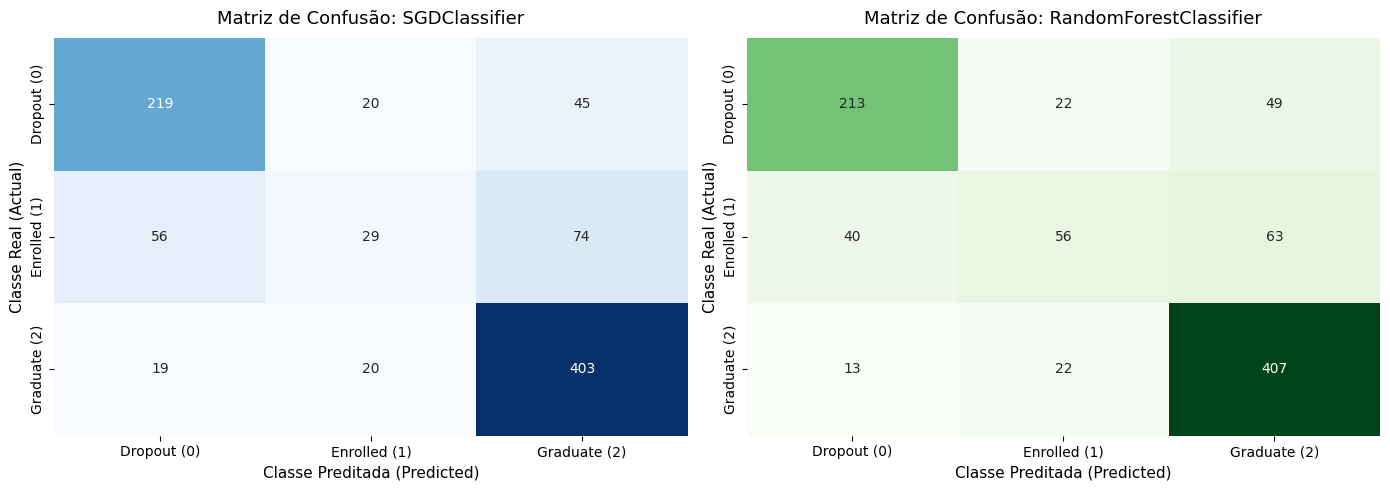


--- Tabela Resumo Comparativa de Desempenho ---


,Modelo,Acurácia Geral,Precisão (Weighted),Recall (Weighted),F1-Score (Weighted)
0,SGDClassifier (Baseline),0.7356,0.7001,0.7356,0.7065
1,RandomForestClassifier,0.7638,0.7492,0.7638,0.7493


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

class_names = ['Dropout (0)', 'Enrolled (1)', 'Graduate (2)']

# 1. Geração dos Relatórios Detalhados
print("=========================================================")
print("          RELATÓRIO DE DESEMPENHO: SGDCLASSIFIER          ")
print("=========================================================")
print(classification_report(y_test, y_pred_sgd, target_names=class_names, digits=4))

print("\n=========================================================")
print("       RELATÓRIO DE DESEMPENHO: RANDOMFORESTCLASSIFIER    ")
print("=========================================================")
print(classification_report(y_test, y_pred_rf, target_names=class_names, digits=4))

# 2. Visualização das Matrizes de Confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz SGDClassifier
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[0].set_title('Matriz de Confusão: SGDClassifier', fontsize=13, pad=10)
axes[0].set_xlabel('Classe Preditada (Predicted)', fontsize=11)
axes[0].set_ylabel('Classe Real (Actual)', fontsize=11)

# Matriz RandomForestClassifier
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[1].set_title('Matriz de Confusão: RandomForestClassifier', fontsize=13, pad=10)
axes[1].set_xlabel('Classe Preditada (Predicted)', fontsize=11)
axes[1].set_ylabel('Classe Real (Actual)', fontsize=11)

plt.tight_layout()
plt.show()

# 3. Tabela Comparativa Resumida
prec_sgd, rec_sgd, f1_sgd, _ = precision_recall_fscore_support(y_test, y_pred_sgd, average='weighted')
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='weighted')

df_comparacao = pd.DataFrame({
    'Modelo': ['SGDClassifier (Baseline)', 'RandomForestClassifier'],
    'Acurácia Geral': [f"{accuracy_score(y_test, y_pred_sgd):.4f}", f"{accuracy_score(y_test, y_pred_rf):.4f}"],
    'Precisão (Weighted)': [f"{prec_sgd:.4f}", f"{prec_rf:.4f}"],
    'Recall (Weighted)': [f"{rec_sgd:.4f}", f"{rec_rf:.4f}"],
    'F1-Score (Weighted)': [f"{f1_sgd:.4f}", f"{f1_rf:.4f}"]
})

print("\n--- Tabela Resumo Comparativa de Desempenho ---")
display(df_comparacao)

### Análise Comparativa e Justificativa do Modelo Escolhido

#### 1. Análise Geral das Métricas
* **Acurácia:** O modelo **RandomForestClassifier** obteve uma acurácia global de **76,38%**, superando o **SGDClassifier**, que alcançou **73,56%** (uma evolução de quase 3 pontos percentuais).
* **F1-Score Ponderado (Weighted F1):** O RandomForest obteve **0,7493**, superior aos **0,7065** obtidos pelo SGD, demonstrando maior consistência ao balancear precisão e revocação entre as três categorias.

#### 2. Comportamento Específico por Classe
* **Classe `Graduate` (2):** Ambos os modelos apresentaram excelente desempenho, com F1-Scores superiores a 0,83 (com Recall acima de 91% em ambos os casos). Isso indica que prever o sucesso final do aluno é a tarefa mais fácil do conjunto de dados.
* **Classe `Dropout` (0):** O RandomForest teve desempenho superior na precisão (**80,08%** no RF vs **74,49%** no SGD) e no F1-Score (**0,7745** no RF vs **0,7578** no SGD), identificando com maior segurança os alunos em real risco de desistência.
* **Classe `Enrolled` (1) — O Maior Desafio:** A classe de alunos matriculados é a menor e mais difícil de prever. O `SGDClassifier` teve extrema dificuldade, obtendo um Recall irrisório de **18,24%** (de 159 alunos matriculados, acertou apenas 29). Já o **RandomForestClassifier** quase dobrou a capacidade de detecção, alcançando um Recall de **35,22%** e um F1-Score de **0,4324** (contra 0,2544 do SGD).

#### 3. Decisão e Escolha do Modelo Final
**Modelo Escolhido:** **`RandomForestClassifier`**

* **Justificativa Técnica:**
  1. **Capacidade de Capturar Não Linearidades:** O `SGDClassifier` é um classificador linear e tenta traçar hiperplanos rígidos entre as classes. Como os dados acadêmicos e socioeconômicos possuem interações complexas e não lineares, a estrutura em conjunto (*ensemble*) do RandomForest superou o SGD em todas as métricas avaliadas.
  2. **Robustez ao Desbalanceamento:** O RandomForest lida significativamente melhor com a classe minoritária (`Enrolled`), reduzindo sensivelmente a taxa de falsos negativos em comparação com o baseline linear.
  3. **Estabilidade Preditiva:** Apresentou o maior F1-Score ponderado e macro, sendo o modelo mais confiável para implementação em ambiente real.



---


## 8. Discussão dos Resultados, Erros e Limitações

### 8.1. Análise Detalhada dos Erros do Modelo Final (RandomForest)

Analisando a Matriz de Confusão do `RandomForestClassifier` (213 acertos para Dropout, 56 para Enrolled e 407 para Graduate), observam-se padrões claros sobre onde o modelo falha e acerta:

1. **Erros na Classe Intermediária (`Enrolled`):**
   * Dos 159 alunos realmente matriculados (`Enrolled`), o modelo classificou incorretamente **63 alunos como `Graduate`** e **40 alunos como `Dropout`**, acertando apenas 56 instâncias.
   * **Causa do Erro:** A classe `Enrolled` representa um estado transitório. Um aluno ainda matriculado possui histórico acadêmico parcial (apenas 1º e 2º semestres) que frequentemente se assemelha muito ao padrão de um futuro graduado (se tiver boas notas) ou de um potencial desistente (se tiver notas baixas), tornando as fronteiras de decisão nebulosas nessa fase do curso.

2. **Falsos Positivos de Sucesso (`Dropout` previsto como `Graduate`):**
   * O modelo classificou **49 alunos evadidos (`Dropout`) como diplomados (`Graduate`)**.
   * **Causa do Erro:** A evasão nem sempre decorre do fraco desempenho acadêmico. Fatores externos e não monitorados de forma contínua no dataset — como problemas pessoais, mudança de cidade ou propostas de trabalho — fazem com que alunos com notas aceitáveis abandonem o curso, enganando o classificador.

3. **Facilidade Preditiva na Formação (`Graduate`):**
   * A classe `Graduate` obteve a menor taxa de erro relativo (407 acertos em 442 alunos, ~92% de recall). Isso ocorre porque manter notas consistentes e aprovação regular na maioria das matérias ao longo dos dois primeiros semestres é uma assinatura preditiva extremamente forte e contínua.

---

### 8.2. Limitações dos Dados e do Experimento

1. **Janela Temporal Limitada:** Os dados acadêmicos do dataset cobrem prioritariamente o 1º e o 2º semestres letivos. Embora os semestres iniciais sejam críticos para a evasão, o modelo não acompanha a evolução do estudante nos anos subsequentes.
2. **Ausência de Variáveis Qualitativas e Psicológicas:** Fatores como motivação, saúde mental, suporte familiar qualitativo e adaptação ao ambiente universitário não estão presentes na base, limitando o teto de acurácia de qualquer algoritmo de machine learning.
3. **Desbalanceamento de Classes:** A classe `Enrolled` representa menos de 18% das amostras. Embora a estratificação tenha preservado essa proporção nos conjuntos de treino e teste, o volume absoluto reduzido dessa classe prejudicou o aprendizado do modelo para identificar alunos nessa situação.

---

### 8.3. Trabalhos Futuros e Propostas de Melhoria

Para evoluir a solução preditiva em iterações futuras, propõem-se as seguintes ações:

1. **Ajuste de Hiperparâmetros (*Tuning*):** Realizar busca exaustiva (*GridSearchCV*) ou aleatória (*RandomizedSearchCV*) nos parâmetros do `RandomForest` (`max_depth`, `min_samples_split`, `criterion`) para reduzir o *overfitting* na classe majoritária.
2. **Técnicas de Reamostragem:** Aplicar algoritmos de sobramostragem como o **SMOTE** (*Synthetic Minority Over-sampling Technique*) no conjunto de treino para contrabalançar artificialmente a classe `Enrolled`.
3. **Ajuste dos Pesos das Classes (*Class Weights*):** Utilizar o parâmetro `class_weight='balanced'` nas abordagens para penalizar mais severamente os erros cometidos nas classes minoritárias.
4. **Engenharia de Recursos (*Feature Engineering*):** Criar atributos derivados, como a proporção entre disciplinas aprovadas e matriculadas ($\frac{\text{Aprovadas}}{\text{Matriculadas}}$) ou a variação percentual de notas entre o 1º e o 2º semestre.

---

## 9. Declaração do Uso de Inteligência Artificial

Em conformidade com as diretrizes do projeto, declaramos o uso de ferramentas de Inteligência Artificial durante o desenvolvimento do trabalho:

* **Ferramenta Utilizada:** oogle Gemini.
* **Finalidade:** 1. Suporte no código de estruturação visual dos gráficos e matrizes de confusão via `seaborn`.
  2. Apoio na revisão de sintaxe de Markdown para organização do relatório técnico.
* **Partes do Trabalho em que foi Utilizada:** Seções 2, 3, 4, 5, 6, 7 e 8.
* **Forma de Verificação:** Todo o código gerado foi executado, testado e validado localmente no Google Colab pela equipe. Os textos e análises críticas foram revisados, interpretados e adaptados pelos integrantes do grupo de acordo com a saída real dos dados.

---

## 10. Divisão de Contribuições da Equipe

* **Samuel Campos dos Santos (`@Tyxiel`):**
  * Configuração do repositório no GitHub e integração do arquivo `data.csv`.
  * Implementação do código de Pré-processamento e Divisão dos Dados (Seções 4 e 5).
  * Gravação do vídeo e explicação das seções 1 a 4.

* **João Pedro Chaves (`@JPChaves1`):**
  * Implementação da Análise Exploratória de Dados - EDA (Seção 3).
  * Treinamento e avaliação do modelo `SGDClassifier` e geração das métricas (Seções 6 e 7).
  * Exposição e explicação do código no vídeo demonstrativo.

* **João Victor dos Santos (`@Joaovitor9821`):**
  * Inspeção estrutural e Análise Descritiva dos Dados (Seção 2).
  * Treinamento e avaliação do modelo `RandomForestClassifier` e Análise dos Erros (Seções 6, 7 e 8).
  * Edição final do notebook e revisão da documentação no `README.md`.